In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib 
import os 
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, 
    classification_report, confusion_matrix, log_loss
)
np.random.seed(42)
tf.random.set_seed(42)
os.environ['TF_CPP_MIN_LOG_LEVEL']='2'
plt.style.use('default')
sns.set_palette('husl')
print(f"Gpu Available: {len(tf.config.list_physical_devices('GPU')) > 0}")


Gpu Available: False


# Load and Prepare the data

In [2]:
# Loading dataset 
path=os.path.join("../Processed/engineered_data.csv")
df=pd.read_csv(path)
df['date']=pd.to_datetime(df['date'])
df=df.sort_values('date').reset_index(drop=True)
print(f"Data Shape: {df.shape}")
exclude_cols = [
    'outcome', 'date', 'result', 'gf', 'ga', 'xg', 'xga',
    'team', 'opponent', 'day_of_week', 'comp', 'round', 'time'
]
feature_cols=[col for col in df.columns if col not in exclude_cols]
X=df[feature_cols].copy()
y=df['outcome'].copy()

# Time based split
split_idx=int(len(df)*0.8)
train_dates=df['date'][:split_idx]
test_dates=df['date'][split_idx:]

# Use mask based split
train_mask=df['date']<=train_dates.max()
test_mask=df['date']>train_dates.max()

X_train, X_test = X[train_mask].copy(), X[test_mask].copy()
y_train, y_test = y[train_mask].copy(), y[test_mask].copy()
print(f"Train Data Shape: {X_train.shape}, Test Data Shape: {X_test.shape}")

#Display class distribution
print(f"\nClass distribution: ")
print(f"Training Set: ")
for outcome, label in [(-1, "Loss"), (0, "Draw"), (1, "Win")]:
    count=(y_train==outcome).sum()
    pct=count/len(y_train)*100
    print(f" {label:6s}: {count:4d} : ({pct:.1f}%)")
print(f"Test set: ")
for outcome, label in [(-1, "Loss"), (0, "Draw"), (1, "Win")]:
    count=(y_test==outcome).sum()
    pct=count/len(y_test)*100
    print(f" {label:6s}: {count:4d} : ({pct:.1f}%)")


Data Shape: (4644, 36)
Train Data Shape: (3726, 28), Test Data Shape: (918, 28)

Class distribution: 
Training Set: 
 Loss  : 1351 : (36.3%)
 Draw  : 1019 : (27.3%)
 Win   : 1356 : (36.4%)
Test set: 
 Loss  :  337 : (36.7%)
 Draw  :  242 : (26.4%)
 Win   :  339 : (36.9%)


# Feature Normalization 

In [3]:
# Normalizing features with StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
print(f"Feature Normalized: ")
print(f"Mean Training: {X_train_scaled.mean():.6f}")
print(f"Std Training: {X_train_scaled.std():.6f}")
print(f"Min Training: {X_train_scaled.min():.6f}")
print(f"Max Training: {X_train_scaled.max():.6f}")

# Enable labels for Neural Network (0,1,2)
label_encoder=LabelEncoder()
y_train_encoded=label_encoder.fit_transform(y_train)
y_test_encoded=label_encoder.transform(y_test)

print(f"Label Encoded: ")
print(f"Original Labels: {sorted(y_train.unique())}")
print(f"Encoded Labels: {sorted(np.unique(y_train_encoded))}")

# Create validation split (80% training, 20% validation)
val_split_idx=int(len(X_train_scaled)*0.8)
X_train_final=X_train_scaled[:val_split_idx]
X_val=X_train_scaled[val_split_idx:]
y_train_final=y_train_encoded[:val_split_idx]
y_val=y_train_encoded[val_split_idx:]

print(f"Final data Splits: ")
print(f"Training: {len(X_train_final)} samples")
print(f"Validation: {len(X_val)} samples")
print(f"Test: {len(X_test_scaled)} samples")

Feature Normalized: 
Mean Training: 0.000000
Std Training: 1.000000
Min Training: -3.880859
Max Training: 6.483584
Label Encoded: 
Original Labels: [np.int64(-1), np.int64(0), np.int64(1)]
Encoded Labels: [np.int64(0), np.int64(1), np.int64(2)]
Final data Splits: 
Training: 2980 samples
Validation: 746 samples
Test: 918 samples


# Building Neural Network Architecture

In [4]:
# NN architecture
n_features=X_train_final.shape[1]
n_classes=3

# Define Architecture
model=models.Sequential([
    # Inuput Layer
    layers.Input(shape=(n_features,)),
    # Hidden Layers
    layers.Dense(128, activation='relu', name='dense_1'),
    layers.BatchNormalization(name='bn_1'),
    layers.Dropout(0.3, name='dropout_1'),

    layers.Dense(64, activation='relu', name='dense_2'),
    layers.BatchNormalization(name='bn_2'),
    layers.Dropout(0.3, name='dropout_2'),

    layers.Dense(32, activation='relu', name='dense_3'),
    layers.BatchNormalization(name='bn_3'),
    layers.Dropout(0.3, name='dropout_3'),

    # Output Layer
    layers.Dense(n_classes, activation='softmax', name='output')
])
print(f"Model Architecture created")
print(f"Model Summary: {model.summary()}")

# Save model architecture to file
architecture_path=os.path.join('../results/nn_model_architecture.txt')
with open(architecture_path, 'w', encoding='utf-8') as f:
    model.summary(print_fn=lambda x: f.write(x + '\n'))
print(f"Model architecture saved to {architecture_path}")

Model Architecture created


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         3,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,043 (58.76 KB)

 Trainable params: 14,595 (57.01 KB)

 Non-trainable params: 448 (1.75 KB)

Model Summary: None


Model architecture saved to ../results/nn_model_architecture.txt


# Compiling Model

In [ ]:
# Model Compiling
# Fix: previously used keras.optimizers.schedules.ExponentialDecay as the
# learning rate and then layered ReduceLROnPlateau on top. ReduceLROnPlateau
# cannot adjust a scheduled LR, so the callback was a no-op. Use a plain
# scalar LR here and let ReduceLROnPlateau manage decay.
initial_learning_rate=0.001

# Optimizer
optimizer=keras.optimizers.Adam(learning_rate=initial_learning_rate)

# Compile
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print(f"Model Compiled")
print(f"Optimizer: Adam")
print(f"Initial Learning Rate: {initial_learning_rate}")
print(f"Loss Function: Sparse Categorical Cross-Entropy")
print(f"Metrics: Accuracy")

# Setup callbacks
early_stopping=callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)
# ModelCheckpoint
checkpoint_path=os.path.join('..', 'Models', 'nn_model.keras')
model_checkpoint=callbacks.ModelCheckpoint(
    checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)
# Reducing Learning Rate on plateau — min_lr must be strictly less than the
# initial LR for the callback to have any effect.
reduce_lr=callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)
# CsvLogger
csv_logger=callbacks.CSVLogger(
    os.path.join('..', 'results', 'nn_model_training.csv'),
)
all_callbacks=[
    early_stopping,
    model_checkpoint,
    reduce_lr,
    csv_logger,
]
print(f"Callbacks configured:")
print(f"Early Stopping: patience=20")
print(f"Model Checkpoint: {checkpoint_path}")
print(f"ReduceLROnPlateau: factor=0.5, patience=10, min_lr=1e-6")
print(f"CsvLogger")

# Train Model

In [ ]:
history=model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=all_callbacks,
    verbose=1
)
print(f"Model training completed.")

# Training Summary
print(f"Training Summary:")
print(f"Total Epochs Run: {len(history.history['loss'])}")
print(f"Best Validation Loss: {min(history.history['val_loss']):.4f} at epoch {np.argmin(history.history['val_loss']) + 1}")
print(f"Best validation Accuracy: {max(history.history['val_accuracy']):.4f} at epoch {np.argmax(history.history['val_accuracy']) + 1}")

Epoch 1/200
93/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3417 - loss: 1.5762
Epoch 1: val_loss improved from None to 1.06665, saving model to ..\Models\nn_model.keras

Epoch 1: finished saving model to ..\Models\nn_model.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3631 - loss: 1.4660 - val_accuracy: 0.4558 - val_loss: 1.0666 - learning_rate: 0.0010
Epoch 2/200
83/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3687 - loss: 1.3044
Epoch 2: val_loss did not improve from 1.06665
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3836 - loss: 1.2608 - val_accuracy: 0.4692 - val_loss: 1.0702 - learning_rate: 0.0010
Epoch 3/200
81/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3764 - loss: 1.2239
Epoch 3: val_loss improved from 1.06665 to 1.06525, saving model to ..\Models\nn_model.keras

Epoch 3: finished saving model to ..\Models\nn_model.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3906 - loss: 1.1933 - val_accuracy: 0.4504 - val_loss: 1.0653 - 

# Load The Model And Evaluate 

In [7]:
# Evaluate Model Performance
print(f"Loading the model from checkpoint")
best_model=models.load_model(checkpoint_path)
print("NN Model Loaded from checkpoint")

# Predictions
y_pred_proba=best_model.predict(X_test_scaled, verbose=0)
y_pred_encoded=np.argmax(y_pred_proba, axis=1)

# Decode predictions back to original labels
y_pred=label_encoder.inverse_transform(y_pred_encoded)
print(f" Predictions generated")

# Compute Metrics
accuracy=accuracy_score(y_test, y_pred)
f1_macro=f1_score(y_test, y_pred, average='macro')
f1_weighted=f1_score(y_test, y_pred, average='weighted')
precision=precision_score(y_test, y_pred, average='weighted')
recall=recall_score(y_test, y_pred, average='weighted')
logloss=log_loss(y_test_encoded, y_pred_proba)
print(f" Neural Network Model Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score (Macro): {f1_macro:.4f}")
print(f"F1 Score (Weighted): {f1_weighted:.4f}")
print(f"Precision (Weighted): {precision:.4f}")
print(f"Recall (Weighted): {recall:.4f}")
print(f"Log Loss: {logloss:.4f}")

# Compute baseline 
baseline_accuracy=y_train.value_counts(normalize=True).max()
print(f" Comparison: ")
print(f"Baseline Accuracy: {baseline_accuracy:.4f} ({baseline_accuracy*100:.2f}%)")
print(f" Improvement over Baseline: {(accuracy - baseline_accuracy)*100:.2f}%")

# Classification Report
print(f"\nClassification Report: ")
report=classification_report(
    y_test, 
    y_pred,
    target_names=['Loss(-1)', 'Draw(0)', 'Win(1)'],
    digits=4
)
print(report)

# Confusion Matrix
cm=confusion_matrix(y_test, y_pred)
print("Confusion Matrix: ")
print(cm)

# Save results to file
results={
    'Model': 'Neural Network',
    'Architecture': '3 Hidden Layers (128,64,32) with Dropout and BatchNorm',
    'Accuracy': accuracy,
    'F1 Score (Macro)': f1_macro,
    'F1 Score (Weighted)': f1_weighted,
    'Precision (Weighted)': precision,
    'Recall (Weighted)': recall,
    'Log Loss': logloss,
    'Epochs Trained': len(history.history['loss']),
    'Best Epoch': np.argmin(history.history['val_loss']) + 1,
    'parameters': best_model.count_params()
}
results_df=pd.DataFrame([results])
results_path=os.path.join('../results/nn_model_performance.csv')
results_df.to_csv(results_path, index=False)
print(f"Model performance results saved to {results_path}")

# Save classifacation report to file
report_path=os.path.join('../results/nn_classification_report.txt')
with open(report_path, 'w', encoding='utf-8') as f:
    f.write("Neural Network Classification Report\n")
    f.write(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)\n\n")
    f.write(f"F1-Score (Macro): {f1_macro:.4f}\n")
    f.write(f"F1-Score (Weighted): {f1_weighted:.4f}\n")
    f.write(f"Precision (Weighted): {precision:.4f}\n")
    f.write(f"Recall (Weighted): {recall:.4f}\n")
    f.write(f"Log Loss: {logloss:.4f}\n\n")
    f.write("Detailed Classification Report:\n")
    f.write(report)
    f.write("\nConfusion Matrix:\n")
    f.write(str(cm))
print(f"Classification report saved to {report_path}")

Loading the model from checkpoint
NN Model Loaded from checkpoint
 Predictions generated
 Neural Network Model Performance:
Accuracy: 0.4760
F1 Score (Macro): 0.3759
F1 Score (Weighted): 0.4119
Precision (Weighted): 0.4295
Recall (Weighted): 0.4760
Log Loss: 1.0439
 Comparison: 
Baseline Accuracy: 0.3639 (36.39%)
 Improvement over Baseline: 11.21%

Classification Report: 
              precision    recall  f1-score   support

    Loss(-1)     0.4595    0.6736    0.5463       337
     Draw(0)     0.2857    0.0165    0.0312       242
      Win(1)     0.5024    0.6077    0.5501       339

    accuracy                         0.4760       918
   macro avg     0.4159    0.4326    0.3759       918
weighted avg     0.4295    0.4760    0.4119       918

Confusion Matrix: 
[[227   5 105]
 [139   4  99]
 [128   5 206]]
Model performance results saved to ../results/nn_model_performance.csv
Classification report saved to ../results/nn_classification_report.txt


# Visualization



Comprehensive visualization saved to: ..\Evaluation\nn_training_evaluation.png


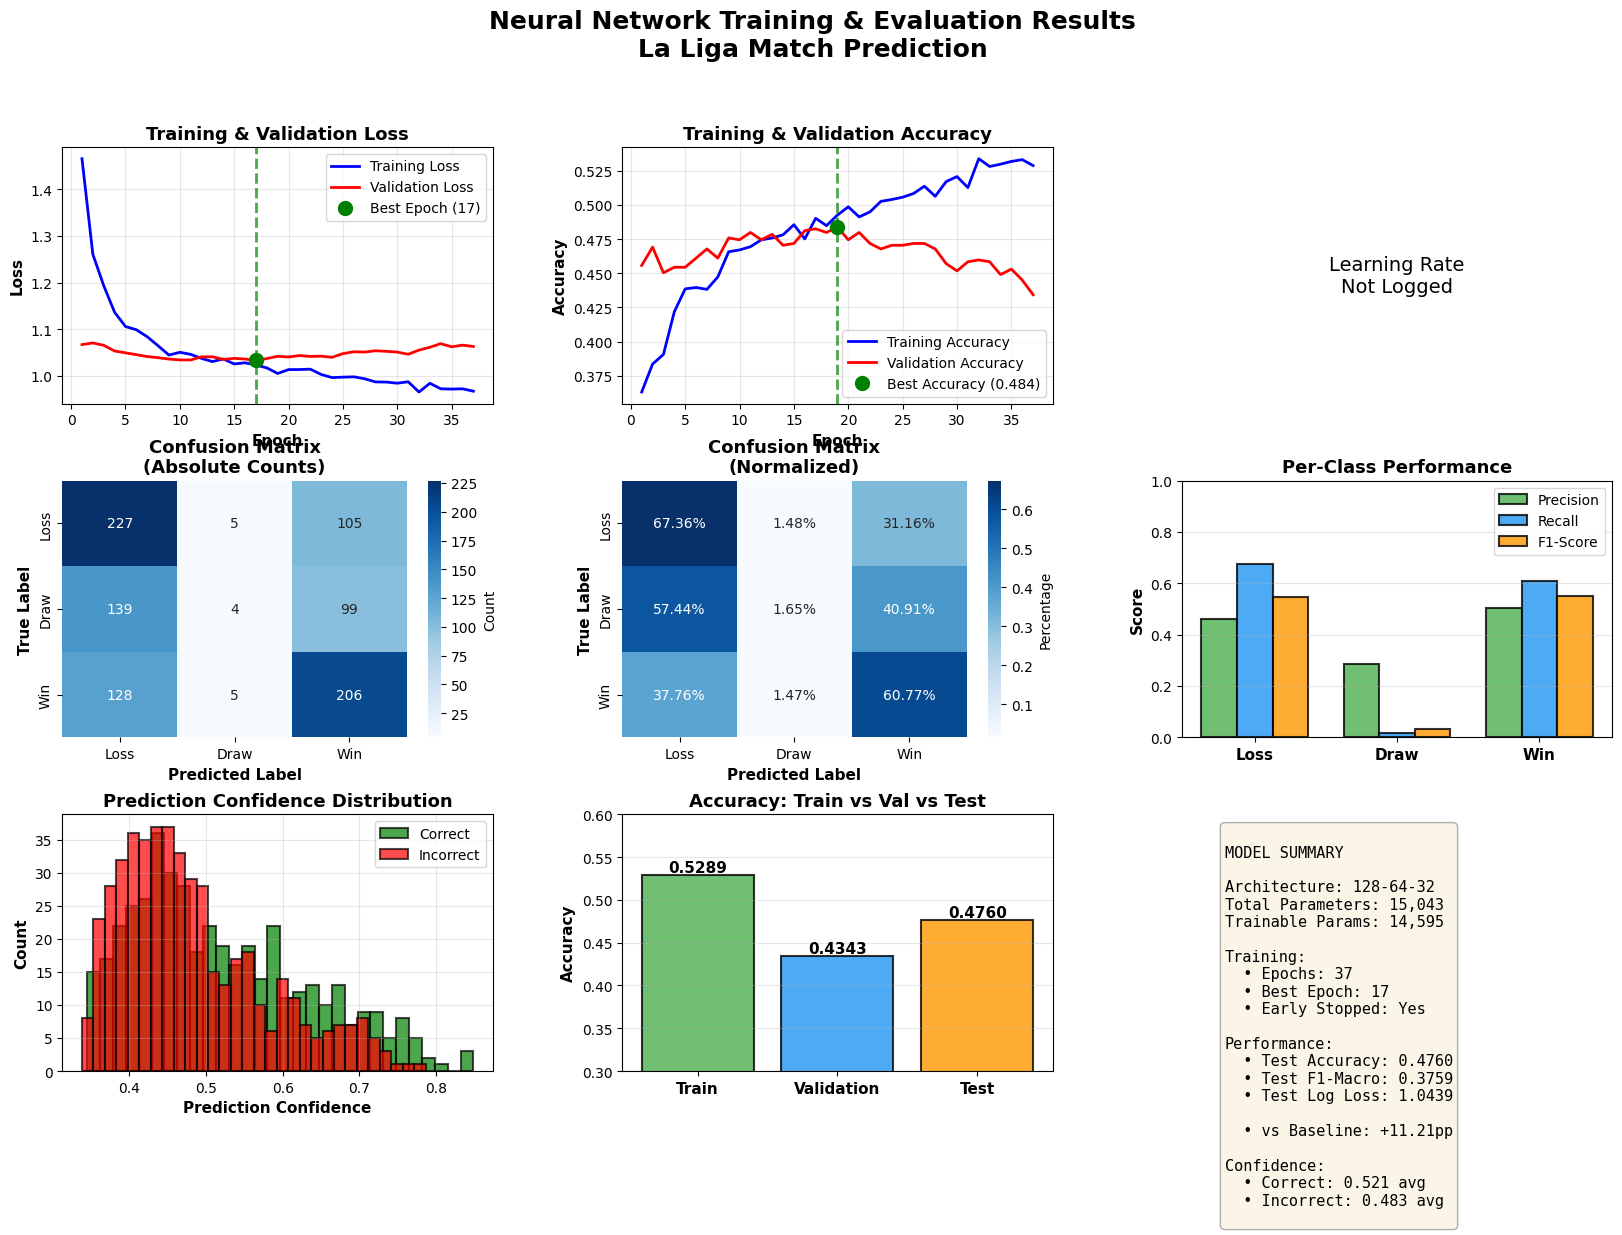

In [9]:
# Create comprehensive visualization
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Training & Validation Loss
ax1 = fig.add_subplot(gs[0, 0])
epochs = range(1, len(history.history['loss']) + 1)
ax1.plot(epochs, history.history['loss'], 'b-', linewidth=2, label='Training Loss')
ax1.plot(epochs, history.history['val_loss'], 'r-', linewidth=2, label='Validation Loss')
best_epoch = np.argmin(history.history['val_loss']) + 1
best_val_loss = min(history.history['val_loss'])
ax1.axvline(best_epoch, color='green', linestyle='--', linewidth=2, alpha=0.7)
ax1.plot(best_epoch, best_val_loss, 'go', markersize=10, label=f'Best Epoch ({best_epoch})')
ax1.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=11, fontweight='bold')
ax1.set_title('Training & Validation Loss', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# 2. Training & Validation Accuracy
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(epochs, history.history['accuracy'], 'b-', linewidth=2, label='Training Accuracy')
ax2.plot(epochs, history.history['val_accuracy'], 'r-', linewidth=2, label='Validation Accuracy')
best_val_acc = max(history.history['val_accuracy'])
best_acc_epoch = np.argmax(history.history['val_accuracy']) + 1
ax2.axvline(best_acc_epoch, color='green', linestyle='--', linewidth=2, alpha=0.7)
ax2.plot(best_acc_epoch, best_val_acc, 'go', markersize=10, label=f'Best Accuracy ({best_val_acc:.3f})')
ax2.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax2.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax2.set_title('Training & Validation Accuracy', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

# 3. Learning Rate Schedule
ax3 = fig.add_subplot(gs[0, 2])
if 'lr' in history.history:
    ax3.plot(epochs, history.history['lr'], 'g-', linewidth=2)
    ax3.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Learning Rate', fontsize=11, fontweight='bold')
    ax3.set_title('Learning Rate Schedule', fontsize=13, fontweight='bold')
    ax3.set_yscale('log')
    ax3.grid(alpha=0.3)
else:
    ax3.text(0.5, 0.5, 'Learning Rate\nNot Logged', 
            ha='center', va='center', fontsize=14, transform=ax3.transAxes)
    ax3.axis('off')

# 4. Confusion Matrix (Absolute)
ax4 = fig.add_subplot(gs[1, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4,
            xticklabels=['Loss', 'Draw', 'Win'],
            yticklabels=['Loss', 'Draw', 'Win'],
            cbar_kws={'label': 'Count'})
ax4.set_title('Confusion Matrix\n(Absolute Counts)', fontsize=13, fontweight='bold')
ax4.set_ylabel('True Label', fontsize=11, fontweight='bold')
ax4.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')

# 5. Confusion Matrix (Normalized)
ax5 = fig.add_subplot(gs[1, 1])
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', ax=ax5,
            xticklabels=['Loss', 'Draw', 'Win'],
            yticklabels=['Loss', 'Draw', 'Win'],
            cbar_kws={'label': 'Percentage'})
ax5.set_title('Confusion Matrix\n(Normalized)', fontsize=13, fontweight='bold')
ax5.set_ylabel('True Label', fontsize=11, fontweight='bold')
ax5.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')

# 6. Per-Class Performance
ax6 = fig.add_subplot(gs[1, 2])
report_dict = classification_report(y_test, y_pred, 
                                    target_names=['Loss', 'Draw', 'Win'],
                                    output_dict=True)
classes = ['Loss', 'Draw', 'Win']
precision_scores = [report_dict[cls]['precision'] for cls in classes]
recall_scores = [report_dict[cls]['recall'] for cls in classes]
f1_scores = [report_dict[cls]['f1-score'] for cls in classes]

x = np.arange(len(classes))
width = 0.25

bars1 = ax6.bar(x - width, precision_scores, width, label='Precision', 
               color='#4CAF50', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax6.bar(x, recall_scores, width, label='Recall',
               color='#2196F3', alpha=0.8, edgecolor='black', linewidth=1.5)
bars3 = ax6.bar(x + width, f1_scores, width, label='F1-Score',
               color='#FF9800', alpha=0.8, edgecolor='black', linewidth=1.5)

ax6.set_xticks(x)
ax6.set_xticklabels(classes, fontsize=11, fontweight='bold')
ax6.set_ylabel('Score', fontsize=11, fontweight='bold')
ax6.set_title('Per-Class Performance', fontsize=13, fontweight='bold')
ax6.legend(fontsize=10)
ax6.set_ylim([0, 1.0])
ax6.grid(axis='y', alpha=0.3)

# 7. Prediction Confidence Distribution
ax7 = fig.add_subplot(gs[2, 0])
max_probs = y_pred_proba.max(axis=1)
correct_mask = (y_pred == y_test.values)
correct_probs = max_probs[correct_mask]
incorrect_probs = max_probs[~correct_mask]

ax7.hist(correct_probs, bins=30, alpha=0.7, label='Correct', 
        color='green', edgecolor='black', linewidth=1.5)
ax7.hist(incorrect_probs, bins=30, alpha=0.7, label='Incorrect',
        color='red', edgecolor='black', linewidth=1.5)
ax7.set_xlabel('Prediction Confidence', fontsize=11, fontweight='bold')
ax7.set_ylabel('Count', fontsize=11, fontweight='bold')
ax7.set_title('Prediction Confidence Distribution', fontsize=13, fontweight='bold')
ax7.legend(fontsize=10)
ax7.grid(alpha=0.3)

# 8. Metrics Comparison (Train vs Val vs Test)
ax8 = fig.add_subplot(gs[2, 1])
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
test_acc = accuracy

metrics_data = {
    'Train': [final_train_acc],
    'Validation': [final_val_acc],
    'Test': [test_acc]
}

x_pos = np.arange(3)
values = [final_train_acc, final_val_acc, test_acc]
colors_bar = ['#4CAF50', '#2196F3', '#FF9800']

bars = ax8.bar(x_pos, values, color=colors_bar, alpha=0.8,
              edgecolor='black', linewidth=1.5)

for bar, val in zip(bars, values):
    height = bar.get_height()
    ax8.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax8.set_xticks(x_pos)
ax8.set_xticklabels(['Train', 'Validation', 'Test'], fontsize=11, fontweight='bold')
ax8.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax8.set_title('Accuracy: Train vs Val vs Test', fontsize=13, fontweight='bold')
ax8.set_ylim([0.3, 0.6])
ax8.grid(axis='y', alpha=0.3)

# 9. Model Summary Stats
ax9 = fig.add_subplot(gs[2, 2])
ax9.axis('off')

summary_text = f"""
MODEL SUMMARY

Architecture: 128-64-32
Total Parameters: {best_model.count_params():,}
Trainable Params: {sum([tf.size(w).numpy() for w in best_model.trainable_weights]):,}

Training:
  • Epochs: {len(history.history['loss'])}
  • Best Epoch: {best_epoch}
  • Early Stopped: {'Yes' if len(history.history['loss']) < 200 else 'No'}

Performance:
  • Test Accuracy: {accuracy:.4f}
  • Test F1-Macro: {f1_macro:.4f}
  • Test Log Loss: {logloss:.4f}

  • vs Baseline: {(accuracy - baseline_accuracy)*100:+.2f}pp

Confidence:
  • Correct: {correct_probs.mean():.3f} avg
  • Incorrect: {incorrect_probs.mean():.3f} avg
"""

ax9.text(0.1, 0.95, summary_text, transform=ax9.transAxes,
        fontsize=11, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle('Neural Network Training & Evaluation Results\nLa Liga Match Prediction',
            fontsize=18, fontweight='bold', y=0.995)

# Save
viz_path = os.path.join('..','Evaluation','nn_training_evaluation.png')
plt.savefig(viz_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"\nComprehensive visualization saved to: {viz_path}")
plt.show()
